## 1. 数据读取
读取原始CSV数据集，初步查看数据结构、变量类型及基本统计信息。

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager as fm
import matplotlib.pyplot as plt

fp = fm.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("Dataset of AI Adoption Usage among Students in Indonesia Higher Education.csv")

F:\python\Anaconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
F:\python\Anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import numpy as np

print(df.head())
print(df.info())
print(df.describe())

  Respondent Gender University  Level of Education  Province  Fields of Study  \
0          1      1          1                 2.0       6.0              3.0   
1          2      1          1                 2.0       4.0              3.0   
2          3      1          1                 2.0       4.0              3.0   
3          4      1          1                 2.0       4.0              0.0   
4          5      2          1                 2.0       4.0              0.0   

   Type of AI  PE1  PE2  PE3  ...  AUP1  AUP2  AUP3  AUP4  AUP5  MIUA1  MIUA2  \
0         3.0  3.0  3.0  3.0  ...   1.0   2.0   3.0   2.0   1.0    2.0    2.0   
1         2.0  1.0  1.0  1.0  ...   1.0   1.0   2.0   1.0   1.0    1.0    1.0   
2         2.0  3.0  2.0  3.0  ...   1.0   2.0   3.0   2.0   1.0    2.0    2.0   
3         2.0  3.0  3.0  3.0  ...   2.0   3.0   3.0   3.0   3.0    3.0    3.0   
4         2.0  3.0  3.0  3.0  ...   2.0   3.0   3.0   3.0   3.0    3.0    3.0   

   MIUA3  MIUA4  MIUA5  
0

## 2. 数据预处理
### 步骤一：删除无关变量
删除仅用于标识编号的 Respondent 字段，不参与后续分析。

In [3]:
df = df.drop(columns=['Respondent'], errors='ignore')

### 步骤二：变量类型转换
将性别、大学、教育层次等人口统计变量转换为分类变量。

In [4]:
categorical_cols = [
    'Gender', 'University', 'Level of Education',
    'Province', 'Fields of Study', 'Type of AI'
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = pd.Categorical(df[col])

### 步骤三：异常值处理
定位所有量表题项，将超出 Likert 量表范围（1–4分）的数值设为缺失值。

In [5]:
scale_cols = [col for col in df.columns if any(prefix in col for prefix in ['PE','CU','ATU','AUP','MIUA'])]

In [6]:
for col in scale_cols:
    df.loc[~df[col].between(1, 4), col] = np.nan

### 步骤四：缺失值处理
删除有效作答比例低于80%的样本，其余缺失值采用均值填补。

In [7]:
df = df.dropna(subset=scale_cols, thresh=int(len(scale_cols)*0.8))

for col in scale_cols:
    df[col] = df[col].fillna(df[col].mean())

In [8]:
df = df.dropna(subset=[
    'Gender', 'University', 'Level of Education',
    'Province', 'Fields of Study', 'Type of AI'
])

In [9]:
print(df[scale_cols].describe())
print(df.isnull().sum())

              PE1         PE2         PE3         PE4         PE5         PE6  \
count  534.000000  534.000000  534.000000  534.000000  534.000000  534.000000   
mean     3.191011    3.054307    3.136704    3.020599    3.067416    3.121723   
std      0.770610    0.744492    0.751510    0.815853    0.744678    0.792895   
min      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   
25%      3.000000    3.000000    3.000000    3.000000    3.000000    3.000000   
50%      3.000000    3.000000    3.000000    3.000000    3.000000    3.000000   
75%      4.000000    4.000000    4.000000    4.000000    4.000000    4.000000   
max      4.000000    4.000000    4.000000    4.000000    4.000000    4.000000   

              PE7         PE8         PE9        PE10  ...        AUP1  \
count  534.000000  534.000000  534.000000  534.000000  ...  534.000000   
mean     3.014981    3.099251    2.958801    2.833333  ...    1.973783   
std      0.821704    0.737293    0.809296    0.8

## 3. 信度分析
定义 Cronbach's Alpha 计算函数，用于检验各维度量表的内部一致性。

In [10]:
import pandas as pd
import numpy as np
def cronbach_alpha(df_items):
    df_items = df_items.dropna()
    k = df_items.shape[1]
    variances = df_items.var(axis=0, ddof=1)
    total_var = df_items.sum(axis=1).var(ddof=1)
    alpha = (k / (k - 1)) * (1 - variances.sum() / total_var)
    return alpha

分别计算 PE、CU、ATU、AUP、MIUA 五个维度的 Cronbach's Alpha 系数。

In [11]:
alpha_PE = cronbach_alpha(df[[f'PE{i}' for i in range(1,21)]])
print("PE alpha:", alpha_PE)

PE alpha: 0.9563319415509383


In [12]:
alpha_CU = cronbach_alpha(df[[f'CU{i}' for i in range(1,5)]])
print("CU alpha:", alpha_CU)

CU alpha: 0.7132582763082884


In [13]:
alpha_ATU = cronbach_alpha(df[[f'ATU{i}' for i in range(1,6)]])
print("ATU alpha:", alpha_ATU)

ATU alpha: 0.8319119125086111


In [14]:
alpha_AUP = cronbach_alpha(df[[f'AUP{i}' for i in range(1,6)]])
print("AUP alpha:", alpha_AUP)

AUP alpha: 0.6718383094362437


In [15]:
alpha_MIUA = cronbach_alpha(df[[f'MIUA{i}' for i in range(1,6)]])
print("MIUA alpha:", alpha_MIUA)

MIUA alpha: 0.8588061777143391


## 4. 变量构建
将同一维度下的多个题项取平均值，构建五个综合指标变量。

In [16]:
df['PE_mean'] = df[[f'PE{i}' for i in range(1,21)]].mean(axis=1)
df['CU_mean'] = df[[f'CU{i}' for i in range(1,5)]].mean(axis=1)
df['ATU_mean'] = df[[f'ATU{i}' for i in range(1,6)]].mean(axis=1)
df['AUP_mean'] = df[[f'AUP{i}' for i in range(1,6)]].mean(axis=1)
df['MIUA_mean'] = df[[f'MIUA{i}' for i in range(1,6)]].mean(axis=1)

In [17]:
final_cols = ['PE_mean','CU_mean','ATU_mean','AUP_mean','MIUA_mean']

print(df[final_cols].describe())

          PE_mean     CU_mean    ATU_mean    AUP_mean   MIUA_mean
count  534.000000  534.000000  534.000000  534.000000  534.000000
mean     3.055134    2.457068    2.870821    2.666667    2.753558
std      0.575594    0.660992    0.615244    0.572062    0.649156
min      1.000000    1.000000    1.000000    1.000000    1.000000
25%      2.750000    2.000000    2.400000    2.400000    2.400000
50%      3.000000    2.500000    3.000000    2.600000    2.800000
75%      3.450000    2.750000    3.200000    3.000000    3.200000
max      4.000000    4.000000    4.000000    4.000000    4.000000


In [18]:
df.to_csv("cleaned_data.csv", index=False)

## 5. 描述性统计分析
### 5.1 人口统计变量分布
绘制教育层次、专业领域、AI工具类型等人口统计变量的频率分布图。

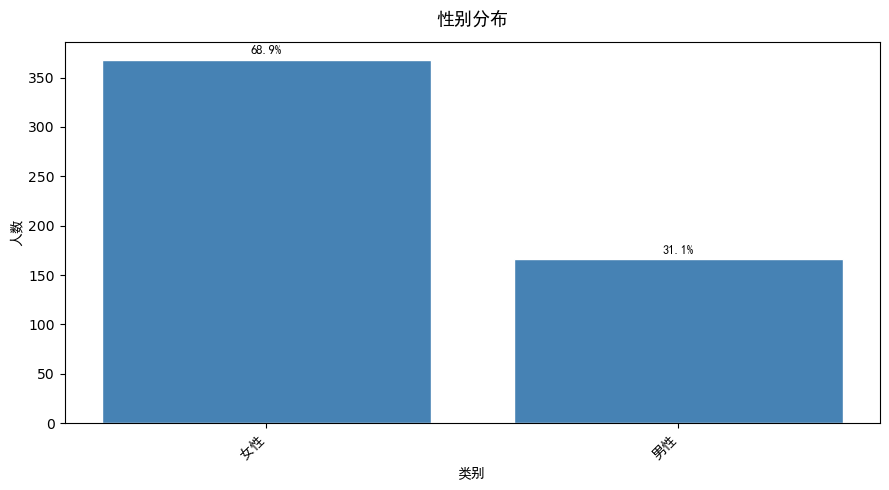

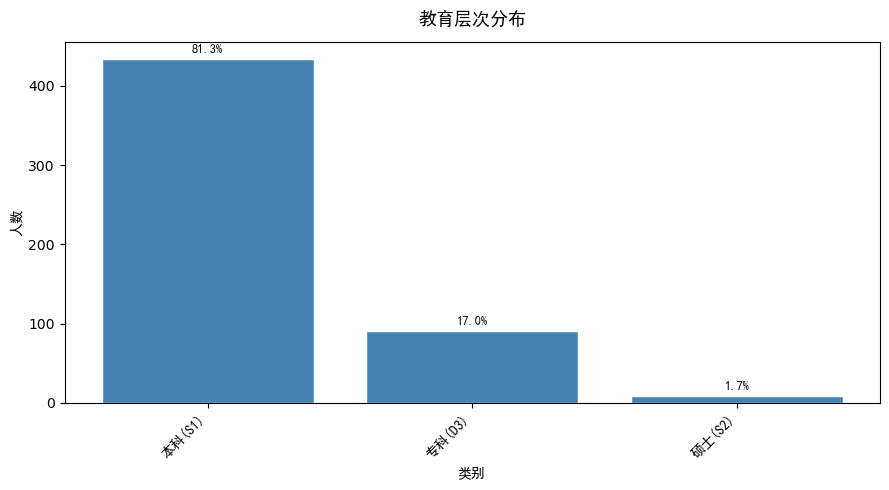

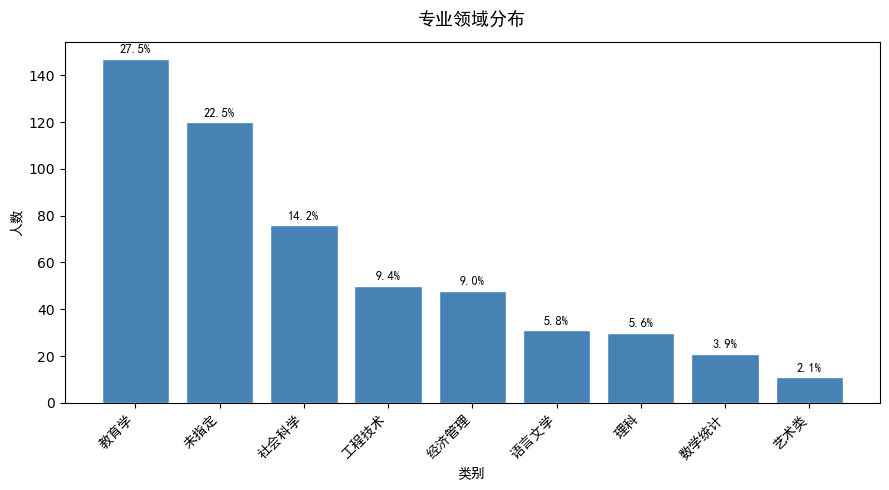

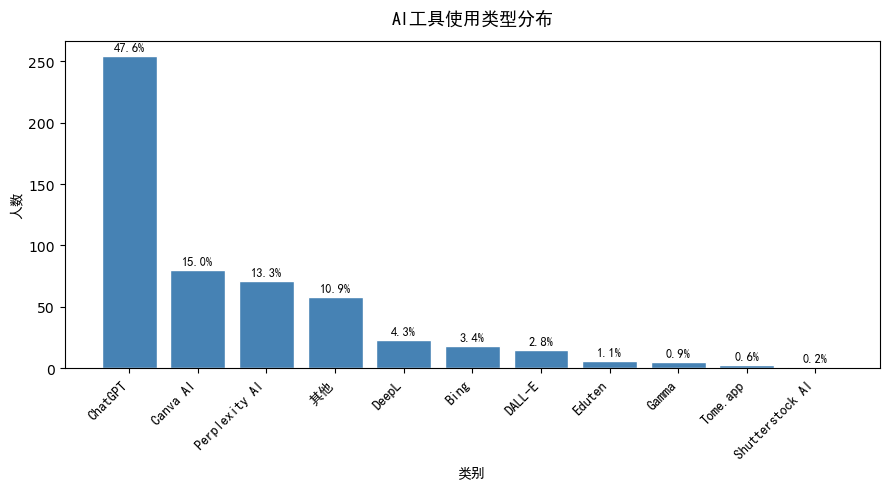

In [19]:
label_maps = {
    'Gender': {
        '1': '男性',
        '2': '女性'
    },
    'Level of Education': {
        '1.0': '专科(D3)',
        '2.0': '本科(S1)',
        '3.0': '硕士(S2)',
        '4.0': '博士(S3)'
    },
    'Fields of Study': {
        '0.0': '未指定',
        '1.0': '理科',        
        '2.0': '社会科学',    
        '3.0': '工程技术',   
        '4.0': '数学统计',    
        '5.0': '语言文学',   
        '6.0': '经济管理',    
        '7.0': '教育学',      
        '8.0': '艺术类'       
    },
    'Type of AI': {
        '1.0':  'DALL-E',
        '2.0':  'Canva AI',
        '3.0':  'ChatGPT',
        '4.0':  'DeepL',
        '5.0':  'Bing',
        '6.0':  'Tome.app',
        '7.0':  'Gamma',
        '9.0':  'Eduten',
        '10.0': 'Shutterstock AI',
        '11.0': 'Perplexity AI',
        '12.0': '其他'
    }
}

demo_configs = [
    ('Gender',             '性别分布'),
    ('Level of Education', '教育层次分布'),
    ('Fields of Study',    '专业领域分布'),
    ('Type of AI',         'AI工具使用类型分布'),
]

for col, title in demo_configs:

    counts = df[col].astype(str).value_counts()
    counts = counts[counts > 0]

    if col in label_maps:
        counts.index = [label_maps[col].get(str(i), str(i)) for i in counts.index]

    percentages = counts / counts.sum() * 100

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(range(len(counts)), counts.values,
           color='steelblue', edgecolor='white')

    for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
        ax.text(i, count + counts.max() * 0.01,
                f'{pct:.1f}%',
                ha='center', va='bottom',
                fontsize=9, fontproperties=fp)

    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=45, ha='right',
                       fontproperties=fp)
    ax.set_title(title, fontproperties=fp, fontsize=13, pad=12)
    ax.set_xlabel('类别', fontproperties=fp)
    ax.set_ylabel('人数', fontproperties=fp)

    plt.tight_layout()
    plt.savefig(f"{col}.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [20]:
demo_cols = [
'Gender',
'University',
'Level of Education',
'Fields of Study',
'Type of AI'
]

for col in demo_cols:
    print("\n", col)
    print(df[col].value_counts(normalize=True)*100)


 Gender
Gender
2                                                                                   68.913858
1                                                                                   31.086142
 East Nusa Tenggara (Capital: Kota Kupang)                                           0.000000
 Papua (Capital:  Jayapura)                                                          0.000000
Arts: Dance, Music, Painting, Visual Communication Design, Drama, Arts Education     0.000000
                                                                                      ...    
West Kalimantan (Capital: Pontianak)                                                 0.000000
West Nusa Tenggara (Capital: Kota Mataram)                                           0.000000
West Sulawesi (Capital:  Mamuju)                                                     0.000000
West bPapua (Capital:  Manokwari)                                                    0.000000
Yogyakarta Special Region (Capital: Yogyakar

### 5.2 核心变量分布
绘制五个综合指标变量的直方图与箱线图，观察各变量的分布特征。

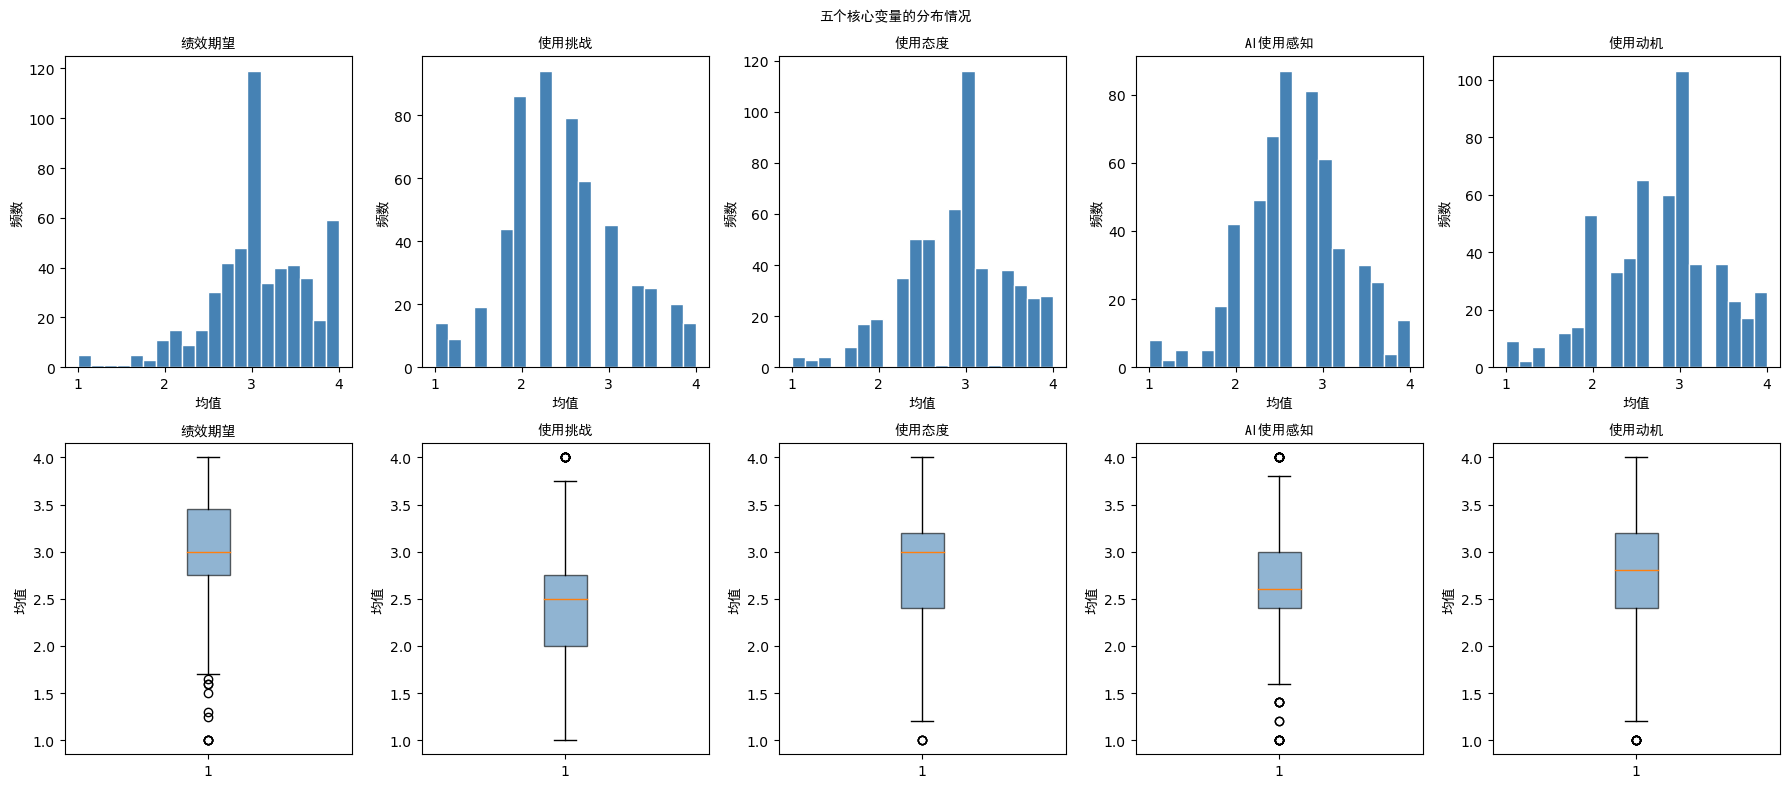

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

var_labels = {
    'PE_mean': '绩效期望',
    'CU_mean': '使用挑战',
    'ATU_mean': '使用态度',
    'AUP_mean': 'AI使用感知',
    'MIUA_mean': '使用动机'
}

for i, (col, label) in enumerate(var_labels.items()):
    axes[0, i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[0, i].set_title(label, fontproperties=fp)
    axes[0, i].set_xlabel('均值', fontproperties=fp)
    axes[0, i].set_ylabel('频数', fontproperties=fp)

    axes[1, i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1, i].set_title(label, fontproperties=fp)
    axes[1, i].set_ylabel('均值', fontproperties=fp)

plt.suptitle('五个核心变量的分布情况', fontproperties=fp)
plt.tight_layout()
plt.show()

### 5.3 相关性分析
计算五个核心变量之间的 Pearson 相关系数矩阵，并绘制热力图。

            PE_mean   CU_mean  ATU_mean  AUP_mean  MIUA_mean
PE_mean    1.000000  0.229601  0.557251  0.479315   0.562302
CU_mean    0.229601  1.000000  0.311567  0.458734   0.302794
ATU_mean   0.557251  0.311567  1.000000  0.575444   0.663528
AUP_mean   0.479315  0.458734  0.575444  1.000000   0.617649
MIUA_mean  0.562302  0.302794  0.663528  0.617649   1.000000


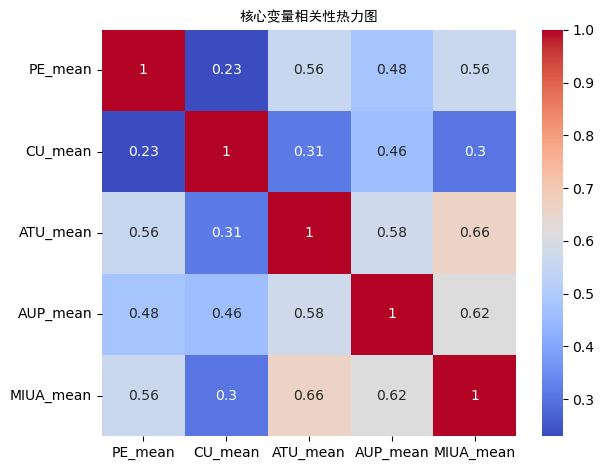

In [22]:
corr_matrix = df[final_cols].corr(method='pearson')
print(corr_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("核心变量相关性热力图", fontproperties=fp)
plt.tight_layout()
plt.show()

In [23]:
from scipy import stats

pairs = [
    ('PE_mean', 'ATU_mean'),
    ('PE_mean', 'MIUA_mean'),
    ('ATU_mean', 'MIUA_mean'),
    ('AUP_mean', 'MIUA_mean'),
    ('CU_mean', 'MIUA_mean'),
]

for x, y in pairs:
    r, p = stats.pearsonr(df[x], df[y])
    print(f"{x} 与 {y}: r={r:.2f}, p={p:.50f}")

PE_mean 与 ATU_mean: r=0.56, p=0.00000000000000000000000000000000000000000000685947
PE_mean 与 MIUA_mean: r=0.56, p=0.00000000000000000000000000000000000000000000076045
ATU_mean 与 MIUA_mean: r=0.66, p=0.00000000000000000000000000000000000000000000000000
AUP_mean 与 MIUA_mean: r=0.62, p=0.00000000000000000000000000000000000000000000000000
CU_mean 与 MIUA_mean: r=0.30, p=0.00000000000087274062545218449420620280747855542771


In [24]:
print(df['Gender'].unique())
print(df['Gender'].value_counts())

['1', '2']
Categories (66, str): [' East Nusa Tenggara (Capital: Kota Kupang)', ' Papua (Capital:  Jayapura)', '1', '2', ..., 'West Nusa Tenggara (Capital: Kota Mataram)', 'West Sulawesi (Capital:  Mamuju)', 'West bPapua (Capital:  Manokwari)', 'Yogyakarta Special Region (Capital: Yogyakarta)']
Gender
2                                                                                   368
1                                                                                   166
 East Nusa Tenggara (Capital: Kota Kupang)                                            0
 Papua (Capital:  Jayapura)                                                           0
Arts: Dance, Music, Painting, Visual Communication Design, Drama, Arts Education      0
                                                                                   ... 
West Kalimantan (Capital: Pontianak)                                                  0
West Nusa Tenggara (Capital: Kota Mataram)                                       

## 6. 方差分析
检验不同性别学生在绩效期望（PE_mean）上是否存在显著差异。

In [25]:
import scipy.stats as stats

groups = df.groupby('Gender')['PE_mean'].apply(list)

f_stat, p_value = stats.f_oneway(*groups)

print("F:", f_stat)
print("p:", p_value)

F: 2.133733767658158
p: 0.14467971980102323


## 7. 多元线性回归分析
以 MIUA_mean 为因变量，PE、CU、ATU、AUP 为自变量，建立回归模型。

In [26]:
import statsmodels.api as sm

X = df[['PE_mean','CU_mean','ATU_mean','AUP_mean']]
y = df['MIUA_mean']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              MIUA_mean   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     163.0
Date:                Sun, 31 May 2026   Prob (F-statistic):           8.28e-91
Time:                        12:20:45   Log-Likelihood:                -312.06
No. Observations:                 534   AIC:                             634.1
Df Residuals:                     529   BIC:                             655.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0129      0.118     -0.109      0.9

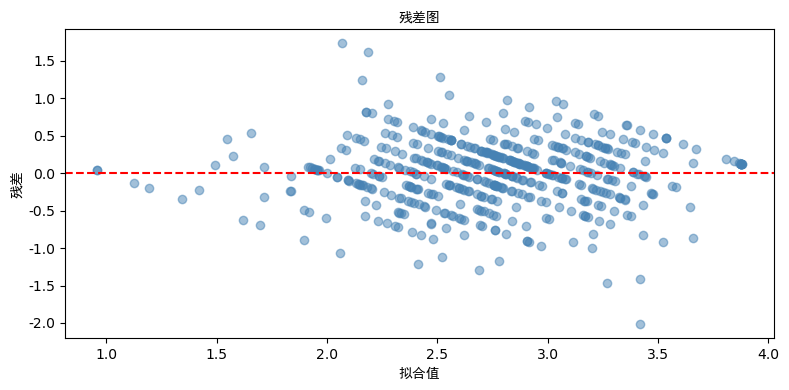

In [27]:
import matplotlib.pyplot as plt

fitted = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8, 4))
plt.scatter(fitted, residuals, alpha=0.5, color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('拟合值', fontproperties=fp)
plt.ylabel('残差', fontproperties=fp)
plt.title('残差图', fontproperties=fp)
plt.tight_layout()
plt.show()

## 8. 多重共线性检验
计算各自变量的方差膨胀因子（VIF），验证回归模型不存在严重共线性问题。

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

    feature        VIF
0     const  39.134358
1   PE_mean   1.534432
2   CU_mean   1.272242
3  ATU_mean   1.774373
4  AUP_mean   1.807451
